In [162]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Picturing vectors in three-dimensional space

## 3D Drawing in Python

In [163]:
from draw3d import *

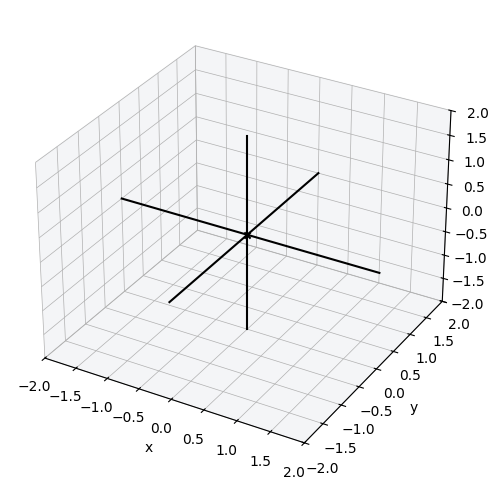

In [164]:
draw3d()

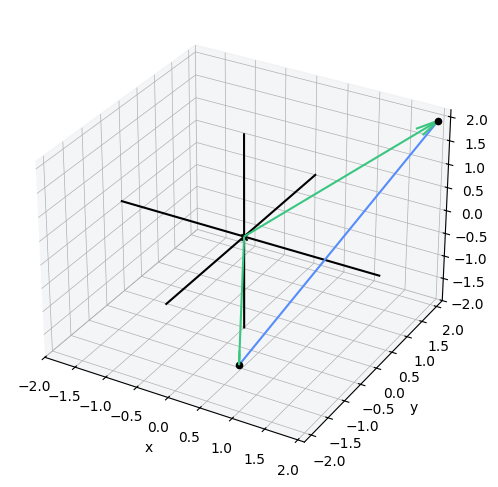

In [165]:
draw3d(
    Points3D((2,2,2),(1,-2,-1)),
    Arrow3D((2,2,2)),
    Arrow3D((1,-2,-1)),
    Segment3D((2,2,2), (1, -2, -1))
)

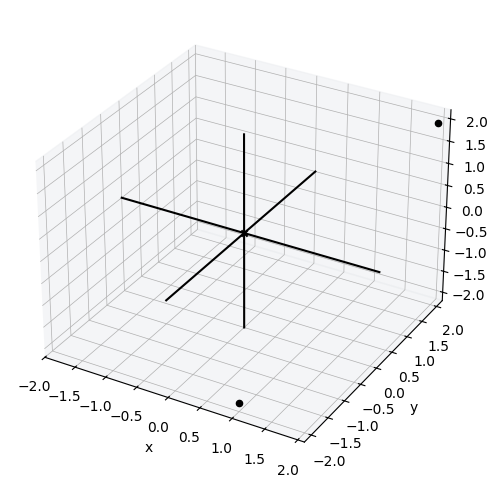

In [166]:
draw3d(
    Points3D((2,2,2),(1,-2,-2))
)

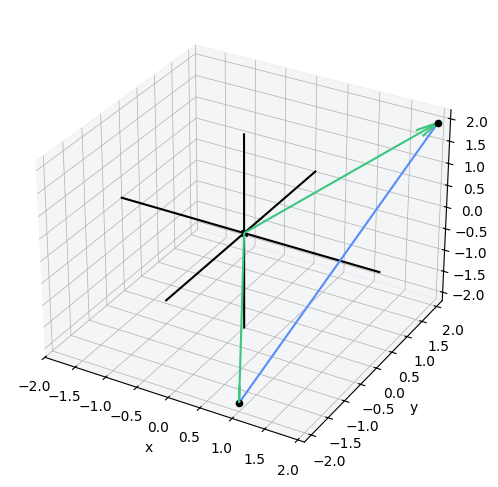

In [167]:
draw3d(
    Points3D((2,2,2),(1,-2,-2)),
    Arrow3D((2,2,2)),
    Arrow3D((1,-2,-2)),
    Segment3D((2,2,2), (1,-2,-2))
)

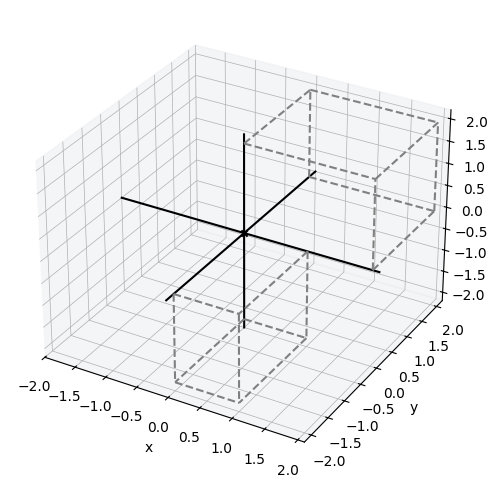

In [168]:
draw3d(
    #Points3D((2,2,2),(1,-2,-2)),
    #Arrow3D((2,2,2)),
    #Arrow3D((1,-2,-2)),
    #Segment3D((2,2,2), (1,-2,-2)),
    Box3D(2,2,2),
    Box3D(1,-2,-2)
)

## Exercises

**Exercise:** Draw the 3D arrow and point representing the coordinates $(-1,-2,2)$, as well as the dashed box that makes the arrow look 3D.  Do this drawing by hand as practice, but from now on we’ll use Python to draw for us.

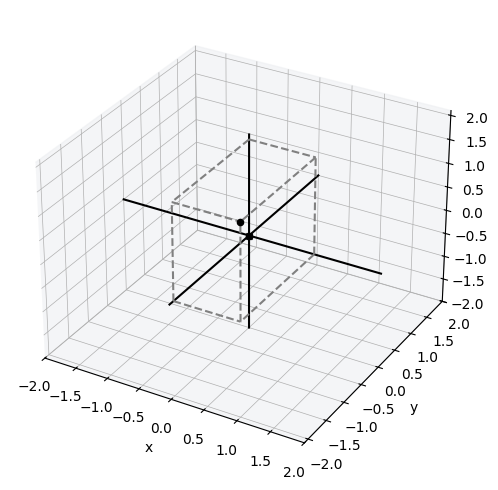

In [169]:
draw3d(
    Points3D((0,0,0), (1,-2,2)),
    Box3D(1,-2,2)
)

**Mini project:** There are eight 3D vectors that have every coordinate equal to $+1$ or $-1$.  For instance, $(1,-1,1)$ is one of them.  Plot all of these eight vectors as points.  Then, figure out how to connect them with line segments (using `Segment3D` objects) to form the outline of a cube.  Hint: you’ll need 12 segments in total.

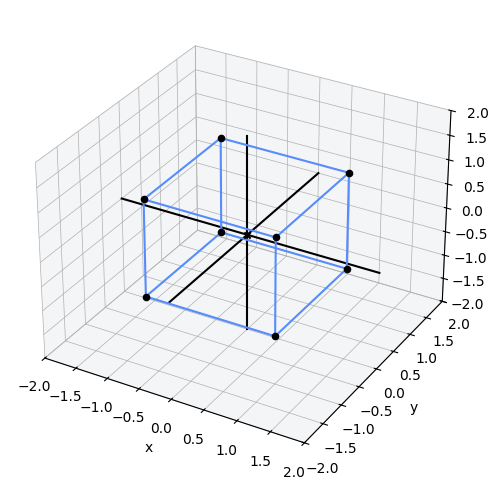

In [170]:
draw3d(
Points3D(
    (-1, -1, -1),
    (-1, -1, +1),
    (-1, +1, -1),
    (-1, +1, +1),
    (+1, -1, -1),
    (+1, -1, +1),
    (+1, +1, -1),
    (+1, +1, +1),
),
    Segment3D((-1, -1, -1), (-1, -1, +1)),
    Segment3D((-1, -1, -1), (-1, +1, -1)),
    Segment3D((-1, +1, -1), (-1, +1, +1)),
    Segment3D((-1, +1, +1), (-1, -1, +1)),
    Segment3D((-1, -1, +1), (+1, -1, +1)),
    Segment3D((+1, -1, +1), (+1, -1, -1)),
    Segment3D((+1, -1, -1), (-1, -1, -1)),
    Segment3D((+1, -1, -1), (+1, +1, -1)),
    Segment3D((+1, +1, -1), (+1, +1, +1)),
    Segment3D((+1, +1, +1), (-1, +1, +1)),
    Segment3D((+1, +1, +1), (+1, -1, +1)),
    Segment3D((+1, +1, -1), (-1, +1, -1)),
)

# Vector arithmetic in 3D

## Adding 3D vectors

In [171]:
def add(*vectors):
    by_coordinate = zip(*vectors)
    coordinate_sums = [sum(coords) for coords in by_coordinate]
    return tuple(coordinate_sums)

In [172]:
list(zip(*[(1,1,3),(2,4,-4),(4,2,-2)]))

[(1, 2, 4), (1, 4, 2), (3, -4, -2)]

In [173]:
[sum(coords) for coords in [(1, 2, 4), (1, 4, 2), (3, -4, -2)]]

[7, 7, -3]

In [174]:
def add(*vectors):
    return tuple(map(sum,zip(*vectors)))

In [175]:
add((1,1,3),(2,4,-4),(4,2,-2))

(7, 7, -3)

## Computing lengths and distances

In [176]:
from math import sqrt
def length(v):
    return sqrt(sum([coord ** 2 for coord in v]))

In [177]:
length((3,4,12))

13.0

## Exercises

**Exercise:** Draw $(4,0,3)$ and $(-1,0,1)$ as Arrow3D objects, such that they are placed tip-to-tail in both orders in 3D.  What is their vector sum?

**Exercise:** Suppose we set `vectors1=[(1,2,3,4,5), (6,7,8,9,10)]` and `vectors2=[(1,2), (3,4), (5,6)]`.  Without evaluating in Python, what are the results of `len(zip(*vectors1))` and `len(zip(*vectors2))`?

**Mini project:** The comprehension below creates a list of 24 Python vectors
```
from math import sin, cos, pi
vs = [(sin(pi*t/6), cos(pi*t/6), 1.0/3) for t in range(0,24)]
```
What is the sum of the 24 vectors?  Draw all 24 of them tip-to-tail as Arrow3D objects.

(0, 0, 0)


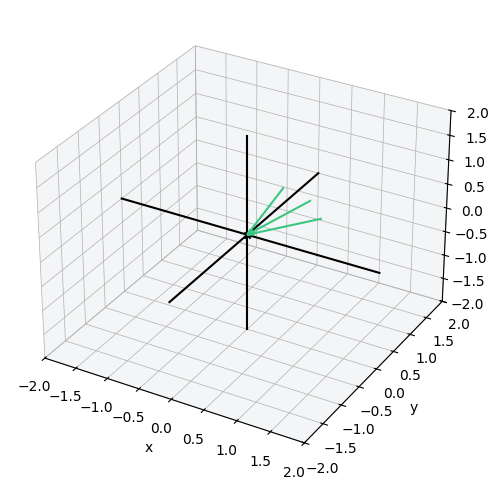

In [178]:
from math import sin, cos, pi
vs = [(sin(pi*t/6), cos(pi*t/6), 1.0/3) for t in range(0,3)]

currentSum = (0,0,0)
arrows = []
for vector in vs:
    nextSum = add(currentSum, vector)
    arrows.append(Arrow3D(currentSum, nextSum))
    # currentSum = nextSum

print(currentSum)
draw3d(
    *arrows
)


**Exercise:** Write a function `scale(scalar,vector)` that returns the input scalar times the input vector.  Specifically, write it so it works on 2D or 3D vectors, or vectors of any number of coordinates.

**Mini project:** The coordinates 3, 4, 12 in any order create a vector of length 13, a whole number. This is unusual because most numbers are not perfect squares, so the square root in the length formula typically returns an irrational number.  Find a different triple of whole numbers that define coordinates of a vector with whole number length.

**Exercise:** Find a vector in the same direction as $(-1,-1,2)$ but which has length 1.  Hint: find the appropriate scalar to multiply the original vector to change its length appropriately.

In [179]:
length((-1,-1,2))

2.449489742783178

In [180]:
s = 1/length((-1,-1,2))

In [181]:
scale(s,(-1,-1,2))

NameError: name 'scale' is not defined

In [ ]:
length(scale(s,(-1,-1,2)))

# The dot product: measuring alignment of vectors

## Computing the dot product

In [ ]:
def dot(u,v):
    return sum([coord1 * coord2 for coord1,coord2 in zip(u,v)])

## Dot products by example

In [ ]:
dot((1,0),(0,2))

In [ ]:
dot((0,3,0),(0,0,-5))

In [ ]:
dot((3,4),(2,3))

In [ ]:
dot(scale(2,(3,4)),(2,3))

In [ ]:
dot((3,4),scale(2,(2,3)))

In [ ]:
dot((4,3),(8,6))

## Measuring angles with the dot product

In [ ]:
from math import cos,pi

In [ ]:
3 * 2 * cos(75 * pi / 180)

In [ ]:
def angle_between(v1,v2):
    return acos(
                dot(v1,v2) /
                (length(v1) * length(v2))
            )

**Mini project:** Find a vector $\vec{u}$ of length 3 and a vector $\vec{v}$ of length 7, such that $\vec{u} \cdot \vec{v} = 21$.  Find another pair of vectors $\vec{u}$ and $\vec{v}$ such that $\vec{u} \cdot \vec{v} = -21$.  Finally, find three more pairs of vectors of respective lengths 3 and 7 and show that all of their lengths lie between -21 and 21.

In [ ]:
from vectors import to_cartesian
from random import random
from math import pi



**Exercise:** Let $\vec{u}$ and $\vec{v}$ be vectors, with $|\vec{u}| = 3.61$ and $|\vec{v}| = 1.44$.  If the angle between $\vec{u}$ and $\vec{v}$ is 101.3 degrees, what is $\vec{u} ∙ \vec{v}$?

**Mini Project:** Find the angle between $(3,4)$ and $(4,3)$ by converting them to polar coordinates and taking the difference of the angles.  

In [ ]:
t2-t1

# The cross product: measuring oriented area

## Computing the cross product of 3D vectors

In [ ]:
def cross(u, v):
    ux,uy,uz = u
    vx,vy,vz = v
    return (uy*vz - uz*vy, uz*vx - ux*vz, ux*vy - uy*vx)

## Exercises

**Exercise:** Use the Python cross function to compute $(0,0,1) \times \vec{v}$ for a few different values of a second vector $\vec{v}$.  What is the $z$-coordinate of each result, and why?

# Rendering a 3D object in 2D

## Defining a 3D object with vectors

In [ ]:
octahedron = [
    [(1,0,0), (0,1,0), (0,0,1)],
    [(1,0,0), (0,0,-1), (0,1,0)],
    [(1,0,0), (0,0,1), (0,-1,0)],
    [(1,0,0), (0,-1,0), (0,0,-1)],
    [(-1,0,0), (0,0,1), (0,1,0)],
    [(-1,0,0), (0,1,0), (0,0,-1)],
    [(-1,0,0), (0,-1,0), (0,0,1)],
    [(-1,0,0), (0,0,-1), (0,-1,0)],
]

In [ ]:
def vertices(faces):
    return list(set([vertex for face in faces for vertex in face]))

In [ ]:
def component(v,direction):
    return (dot(v,direction) / length(direction))

In [ ]:
def vector_to_2d(v):
    return (component(v,(1,0,0)), component(v,(0,1,0)))

In [ ]:
def face_to_2d(face):
    return [vector_to_2d(vertex) for vertex in face]

## Orienting faces and shading

In [ ]:
blues = matplotlib.colormaps.get_cmap('Blues')

In [ ]:
def unit(v):
    return scale(1./length(v), v)

In [ ]:
def normal(face):
    return(cross(subtract(face[1], face[0]), subtract(face[2], face[0])))

In [ ]:
from vectors import *
from draw2d import *

In [ ]:
def render(faces, light=(1,2,300), color_map=blues, lines=None):
    polygons = []
    for face in faces:
        unit_normal = unit(normal(face)) #1
        if unit_normal[2] > 0: #2
            c = color_map(1 - dot(unit(normal(face)), unit(light))) #3
            p = Polygon2D(*face_to_2d(face), fill=c, color=lines) #4
            polygons.append(p)
    draw2d(*polygons,axes=False, origin=False, grid=None)

In [ ]:
render(octahedron, color_map=matplotlib.colormaps.get_cmap('Blues'), lines=black)

In [ ]:
def split(face):
    midpoints = [unit(add(face[i], face[(i+1)%len(face)])) for i in range(0,len(face))]
    triangles = [(face[i], midpoints[i], midpoints[(i-1)%len(face)]) for i in range(0,len(face))]
    return [midpoints] + triangles

def rec_split(faces, depth=0):
    if depth == 0:
        return faces
    else:
        return rec_split([new_face for face in faces for new_face in split(face)], depth-1)

# NICE SPHERE!
def sphere_approx(n):
    return rec_split(octahedron,n)

In [ ]:
render(sphere_approx(3), lines='k')

## Exercises

**Mini project:** Find pairs of vectors defining each of the 12 edges of the octahedron, and draw all of the edges in Python.